In [1]:
import numpy as np
import cirq

# 01 Cirq Basics

Goal: learn qubits, gates, operations, circuits, measurements, simulators, and shots.

In [14]:
#Hello world
qubit = cirq.GridQubit(0,0)

# creating a ciruit
circuit_exp = cirq.Circuit(cirq.X(qubit) ** 0.5, cirq.measure(qubit, key='m'))
print(circuit_exp)

print("Simulating several times")
simulator = cirq.Simulator()
results = simulator.run(circuit, repetitions= 20)
print("Resuls")
print(results)


(0, 0): ───X^0.5───M('m')───
Simulating several times
Resuls
m=10100100101100000101, 10100100101100000101


Quantum registers

In [24]:
print("Naming qubits")
q0 = cirq.NamedQubit('qubit0') #it follows lexicographic order qubit1 is before qubit22.
print("Range qubits")
q_line = cirq.LineQubit(2) + 1 - 1#qubits can be increased or decrease by integers
print("Grid qubits")
q_line = cirq.GridQubit(4,5) #define the rectangular lattice of qubits
q_line = cirq.GridQubit.square(4) #define the square lattice of qubits

print('')
print('Uploading devices directly for more realisty connectivity problems')
import cirq_google
import networkx as nx
my_device = cirq_google.Sycamore
print(my_device)


Naming qubits
Range qubits
Grid qubits

Uploading devices directly for more realisty connectivity problems
                                             (0, 5)───(0, 6)
                                             │        │
                                             │        │
                                    (1, 4)───(1, 5)───(1, 6)───(1, 7)
                                    │        │        │        │
                                    │        │        │        │
                           (2, 3)───(2, 4)───(2, 5)───(2, 6)───(2, 7)───(2, 8)
                           │        │        │        │        │        │
                           │        │        │        │        │        │
                  (3, 2)───(3, 3)───(3, 4)───(3, 5)───(3, 6)───(3, 7)───(3, 8)───(3, 9)
                  │        │        │        │        │        │        │        │
                  │        │        │        │        │        │        │        │
         (4, 1)───(4, 2)───(4, 3)───(4,

In [30]:
print("the actual connectivity might invalidade some 2 qubit gates")
print("Validade method run across gates and errors in this direction")
op1=cirq.H(cirq.GridQubit(6,8))

try:  
    my_device.validate_operation(op1)
except Exception as e:
    print(e) 

the actual connectivity might invalidade some 2 qubit gates
Validade method run across gates and errors in this direction
Qubit not on device: cirq.GridQubit(6, 8).


## Operation and gates!

gates can be applied to qubits, operation is when you apply the gate. Both are immutable objs. 

In [76]:
q0 = cirq.NamedQubit("q0")
q1 = cirq.NamedQubit("q1")
q2 = cirq.NamedQubit("q2")

print("Gate Hadamard")
cirq.H
print("Hadamard operation ")
cirq.H(cirq.GridQubit(1,1))

print()
print("Possible 1 qubti gates")
display(cirq.H, cirq.X, cirq.Y, cirq.Z, cirq.T, cirq.S)
display(cirq.rx(np.pi/2), cirq.rz(np.pi/2), cirq.ry(np.pi/2)) 
print("Like X,Y,Z evolution exp(i pi t/2)")
display(cirq.HPowGate(exponent=2.), cirq.XPowGate(exponent=2.), cirq.YPowGate(exponent=2.), cirq.ZPowGate(exponent=2.))
print("2 plane rotations XY, like z(-p)--X(t)--Z(p)")
display(cirq.PhasedXPowGate(exponent=2., phase_exponent=1.))
print("Aritimetics works like square roots cirq.X **0.5")
print("Making controlled virsion of gates")
display(cirq.X.controlled()) # Gate controlled
display(cirq.X(cirq.GridQubit(1,1)).controlled_by(cirq.GridQubit(1,2))) # Controlled operation


print()
print()
print("2 qubit Gates")
display(cirq.CZ(q0,q1), cirq.CZPowGate(exponent=1.)) #q0 is the control
display(cirq.CNOT(q0,q1), cirq.SWAP(q0,q1), cirq.ISWAP(q0,q1))
display(cirq.XX(q0,q1),cirq.YY(q0,q1),cirq.ZZ(q0,q1))

print()
print()
print("Especial Gates")
print("Unitary matrix from numpy")
cirq.MatrixGate(np.array([[1, 0], [0, 1]]))(q0)
print("Wait matrix ")
display(cirq.WaitGate(cirq.Duration(millis=1000))(q0))

#display(cirq.WaitGate(cirq.Duration(seconds=1.0))) # Useful for T1 and T2 measurements 

display(cirq.TOFFOLI(q0,q1,q2)) 
display(cirq.CCNOT(q0,q1,q2))
display(cirq.FREDKIN(q0,q1,q2))
display(cirq.TwoQubitDiagonalGate)
display(cirq.ThreeQubitDiagonalGate)
display(cirq.QubitPermutationGate)

Gate Hadamard
Hadamard operation 

Possible 1 qubti gates


cirq.H

cirq.X

cirq.Y

cirq.Z

...

cirq.TOFFOLI(cirq.NamedQubit('q0'), cirq.NamedQubit('q1'), cirq.NamedQubit('q2'))

cirq.FREDKIN(cirq.NamedQubit('q0'), cirq.NamedQubit('q1'), cirq.NamedQubit('q2'))

cirq.ops.two_qubit_diagonal_gate.TwoQubitDiagonalGate

cirq.ops.three_qubit_gates.ThreeQubitDiagonalGate

cirq.ops.permutation_gate.QubitPermutationGate

## Bulding circuits

Moments are a collection of operations (vertical line of the circuit)

In [20]:
qubits = cirq.LineQubit.range(3)
circuit = cirq.Circuit()

for j in range(3):
    circuit.append(cirq.H(qubits[j]))
print(circuit)

print()
print("Controlling the moments")
print(cirq.Circuit(cirq.Moment([cirq.H(q)]) for q in cirq.LineQubit.range(3)))

print()
print("Types of appending")
ops = [cirq.H(q) for q in cirq.LineQubit.range(3)]
circuit.append(ops)
print(circuit)

circuit.append(cirq.H(q) for q in cirq.LineQubit.range(3))
print(circuit)

print()
print("Initialized version")
print(cirq.Circuit(cirq.H(q) for q in cirq.LineQubit.range(3)))

0: ───H───

1: ───H───

2: ───H───

Controlling the moments
0: ───H───────────

1: ───────H───────

2: ───────────H───

Types of appending
0: ───H───H───

1: ───H───H───

2: ───H───H───
0: ───H───H───H───

1: ───H───H───H───

2: ───H───H───H───

Initialized version
0: ───H───

1: ───H───

2: ───H───


In [ ]:
qubits = cirq.LineQubit.range(7)
print(cirq.Circuit(cirq.ISWAP(q,q+1) for q in qubits))

0: ───iSwap───────────────────────────────────────────────────
      │
1: ───iSwap───iSwap───────────────────────────────────────────
              │
2: ───────────iSwap───iSwap───────────────────────────────────
                      │
3: ───────────────────iSwap───iSwap───────────────────────────
                              │
4: ───────────────────────────iSwap───iSwap───────────────────
                                      │
5: ───────────────────────────────────iSwap───iSwap───────────
                                              │
6: ───────────────────────────────────────────iSwap───iSwap───
                                                      │
7: ───────────────────────────────────────────────────iSwap───


### Device awareness

In [31]:
import cirq_google
Syc_dev = cirq_google.Sycamore
print(Syc_dev)

q0 = cirq.GridQubit(0,5)
q1 = cirq.GridQubit(0,6)
q2 = cirq.GridQubit(1,4)

#Creating Sycamore op. with adjancent qubit and non-adjacent qubits
adjacent_op = cirq_google.SYC(q0,q1)
nonadjacent_op = cirq_google.SYC(q0,q2)


# Running the circuit - No issues yet
circuit = cirq.Circuit()
circuit.append(adjacent_op)
print("Validating append for adjacent")
display(cirq_google.Sycamore.validate_circuit(circuit))

circuit.append(nonadjacent_op)
try:
    cirq_google.Sycamore.validate_circuit(circuit)
except ValueError as e:
    print(e)

                                             (0, 5)───(0, 6)
                                             │        │
                                             │        │
                                    (1, 4)───(1, 5)───(1, 6)───(1, 7)
                                    │        │        │        │
                                    │        │        │        │
                           (2, 3)───(2, 4)───(2, 5)───(2, 6)───(2, 7)───(2, 8)
                           │        │        │        │        │        │
                           │        │        │        │        │        │
                  (3, 2)───(3, 3)───(3, 4)───(3, 5)───(3, 6)───(3, 7)───(3, 8)───(3, 9)
                  │        │        │        │        │        │        │        │
                  │        │        │        │        │        │        │        │
         (4, 1)───(4, 2)───(4, 3)───(4, 4)───(4, 5)───(4, 6)───(4, 7)───(4, 8)───(4, 9)
         │        │        │        │        │        │   

None

Qubit pair is not valid on device: (cirq.GridQubit(0, 5), cirq.GridQubit(1, 4)).


### Simulator (20 qubits limit)

simulate(): Classical circuit with wave function view. 

run(): Quantum circuit with just end results

In [42]:
q0 = cirq.NamedQubit("q0")
q1 = cirq.NamedQubit("q1")

Bell_circuit=cirq.Circuit()
Bell_circuit.append(cirq.H(q0))
Bell_circuit.append(cirq.CNOT(q0,q1))
print(Bell_circuit)

s = cirq.Simulator()
results = s.simulate(Bell_circuit)
print(results)

print()
print("Measuring")
Bell_circuit.append(cirq.measure(q0,q1, key='result'))
print(Bell_circuit)
samples=s.run(Bell_circuit, repetitions=1000)

q0: ───H───@───
           │
q1: ───────X───
measurements: (no measurements)

qubits: (cirq.NamedQubit('q0'), cirq.NamedQubit('q1'))
output vector: 0.707|00⟩ + 0.707|11⟩

phase:
output vector: |⟩

Measuring
q0: ───H───@───M('result')───
           │   │
q1: ───────X───M─────────────


### Virtual Machine Simulation 

Quantum harware device simualtion! 

Virtual Engine interface: run and verify same interface as the actual hardware.

noise models: tries to replicate realist noise in hardware.

This is important to figure out how to be less impacted by noise on your circuit. 

## Visualization

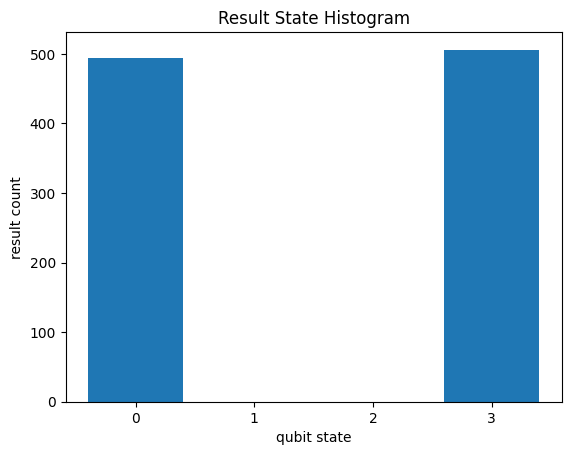

If the system is too sparse in 0 bits, we plot just nonzero


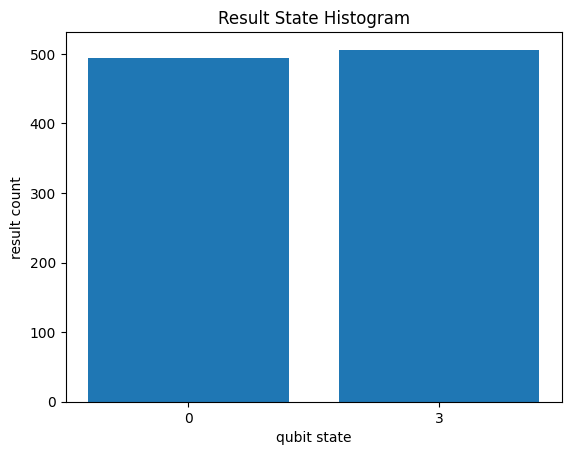

In [46]:
import matplotlib.pyplot as plt

cirq.plot_state_histogram(samples, plt.subplot())
plt.show()
print("If the system is too sparse in 0 bits, we plot just nonzero")
counts = samples.histogram(key='result')
cirq.plot_state_histogram(counts, plt.subplot())
plt.show()

<Axes: title={'center': 'Result State Histogram'}, xlabel='qubit state', ylabel='result count'>

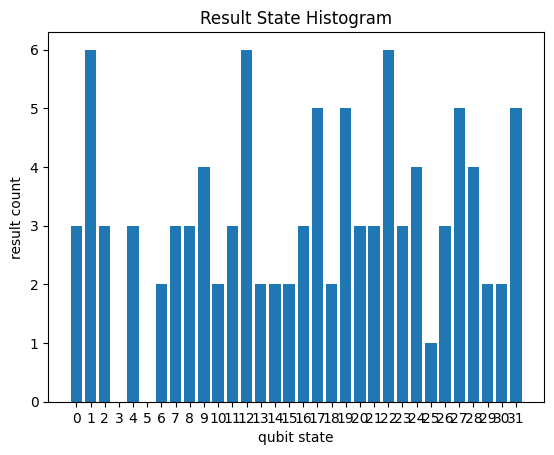

In [64]:
qubits = cirq.LineQubit.range(5)
circuit=cirq.Circuit()
circuit.append(cirq.H(q) for q in qubits)

s = cirq.Simulator()
circuit.append(cirq.measure(q) for q in qubits)
results= s.run(circuit, repetitions=100)

cirq.plot_state_histogram(results, plt.subplot())

pass function to histogram, like even or odd bits


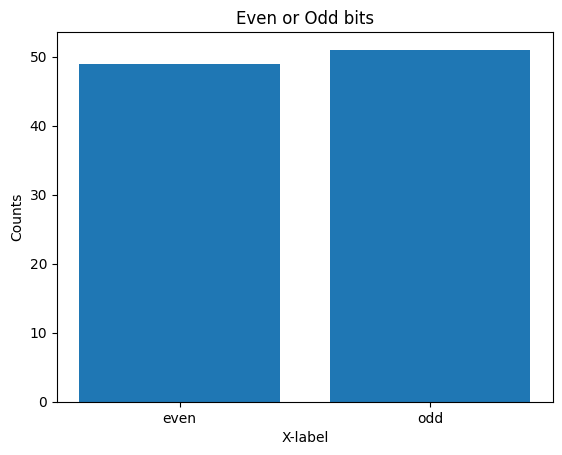

In [76]:
print("pass function to histogram, like even or odd bits")

def count_ones(bits):
    return 'even' if sum(bits) % 2 == 0 else 'odd'

q = cirq.LineQubit.range(9)
circuit = cirq.Circuit([cirq.H.on_each(*q), cirq.measure(*q, key='measure_all')])
result=cirq.Simulator().run(circuit, repetitions=100)

custom_histogram = result.histogram(key='measure_all', fold_func=count_ones)
_ = cirq.plot_state_histogram(
    custom_histogram,
    plt.subplot(),
    title='Even or Odd bits',
    xlabel='X-label',
    ylabel='Counts',
    #tick_label=binary_label(3),
    )

### Parameter sweep

Useful for variational algorithms to optimize a cost function. Possibilities

In [ ]:
import cirq

q0, q1 = cirq.LineQubit.range(2)
circuit = cirq.Circuit(cirq.H(q0), cirq.CNOT(q0, q1), cirq.measure(q0, q1, key='m'))
print(circuit)

0: ───H───@───M('m')───
          │   │
1: ───────X───M────────


In [3]:
result = cirq.Simulator().run(circuit, repetitions=1000)
result.histogram(key='m')

Counter({3: 516, 0: 484})

The Bell circuit prepares roughly equal counts for `00` and `11`. The exact counts fluctuate because we sample finite shots.